## Iowa County Enumeration

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
from pathlib import Path
from src.read import read_graph_from_json
from src.utils import get_roots
from src.experiment import run_enumeration_experiment
from src.draw import visualize_roots
import os
import matplotlib.pyplot as plt

ROOT_DIR = Path.cwd().parents[1]
sys.path.insert(0, str(ROOT_DIR))


os.makedirs("../../results", exist_ok=True)

In [9]:
G_ia = read_graph_from_json("../../data/IA_blockgroup.json", state="IA")

print(
    f"Iowa county graph: {G_ia.number_of_nodes()} nodes, {G_ia.number_of_edges()} edges"
)

Iowa county graph: 2703 nodes, 7325 edges


Root node: [2375, 1533, 557, 1692]


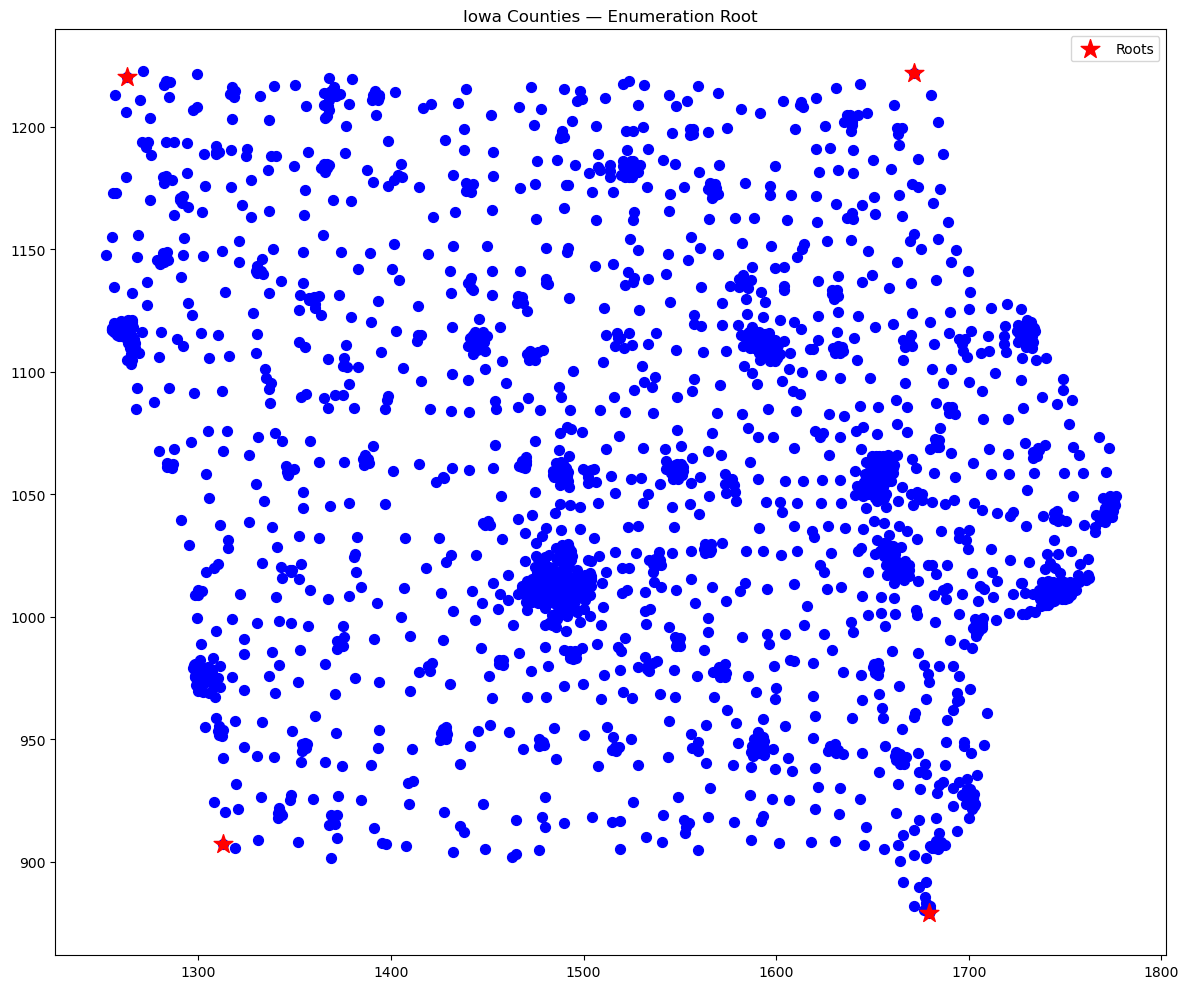

In [10]:
# SE corner as single root for k=2 enumeration
roots = get_roots(G_ia, k=4, root_strategy="corner")
print(f"Root node: {roots}")

fig = visualize_roots(G_ia, roots, title="Iowa Counties — Enumeration Root")
plt.show()

In [ ]:
DEVIATIONS = [20]
CONTIGUITY = ["dag"]
POOL_SIZE = 100
TIME_LIMIT = 3600
K = 4

print(f"Deviations : {DEVIATIONS}")
print(f"Contiguity : {CONTIGUITY}")
print(f"Total runs : {len(DEVIATIONS) * len(CONTIGUITY)}")

In [ ]:
df = run_enumeration_experiment(
    G_base=G_ia,
    deviations=DEVIATIONS,
    contiguity_models=CONTIGUITY,
    root=roots,
    k=K,
    distance_metric="euclidean",
    pool_size=POOL_SIZE,
    time_limit=TIME_LIMIT,
    results_file="../../results/IA_county_enumeration.csv",
)